In [1]:
import numpy as np


def sin(x):
    return np.sin(x)


x = np.linspace(0, np.pi / 2, 10000)
y = sin(x)
np.trapz(y, x)

0.9999999979434211

In [3]:
-np.cos(np.pi / 2) - -np.cos(0)

0.9999999999999999

In [10]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
import string

ALPHABET = list(string.ascii_lowercase)
LOOSE_DASH = (10, (5, 10))

# 1D Hydrogen Chain

In [11]:
def get_labels(Ncell, Natom, numeric=True):

    cell_labels = [[i] * Natom for i in range(1, Ncell + 1)]
    cell_labels = np.array(cell_labels).flatten()
    if numeric:
        atom_labels = [i for i in range(1, Natom + 1)] * Ncell
    else:
        atom_labels = ALPHABET[:Natom] * Ncell
    labels = list(zip(cell_labels, atom_labels))
    return labels


def get_pos(label, a, tau):

    cell, atom = label
    R = a * (cell - 1) + tau * (atom - 1)
    return np.round(R, 8)


def get_index(label, Natom):

    cell, atom = label
    index = (cell - 1) * Natom + atom - 1
    return index


def get_K(label, Ncell, a):
    b = 2 * np.pi / (a * Ncell)
    K = get_pos(label, b, tau=0)
    return K


def get_H(Ncell):

    H = np.matrix(np.zeros((Ncell, Ncell)))

    for cell in range(Ncell - 1):

        H[cell, cell + 1] = -1
        H[cell + 1, cell] = -1

    H[0, Ncell - 1] = -1
    H[Ncell - 1, 0] = -1

    return H


def get_F(Ncell):

    F = np.matrix(np.zeros((Ncell, Ncell)), dtype=complex)
    labels = get_labels(Ncell, Natom=1)

    for i in range(Ncell):

        ri = get_pos(labels[i], a=1, tau=0)
        for j in range(Ncell):

            kj = get_K(labels[j], Ncell, a=1)
            F[i, j] = np.exp(1j * kj * ri) / np.sqrt(Ncell)

    return F


def get_Hk(H, F):

    Hk = F.H @ H @ F

    return Hk

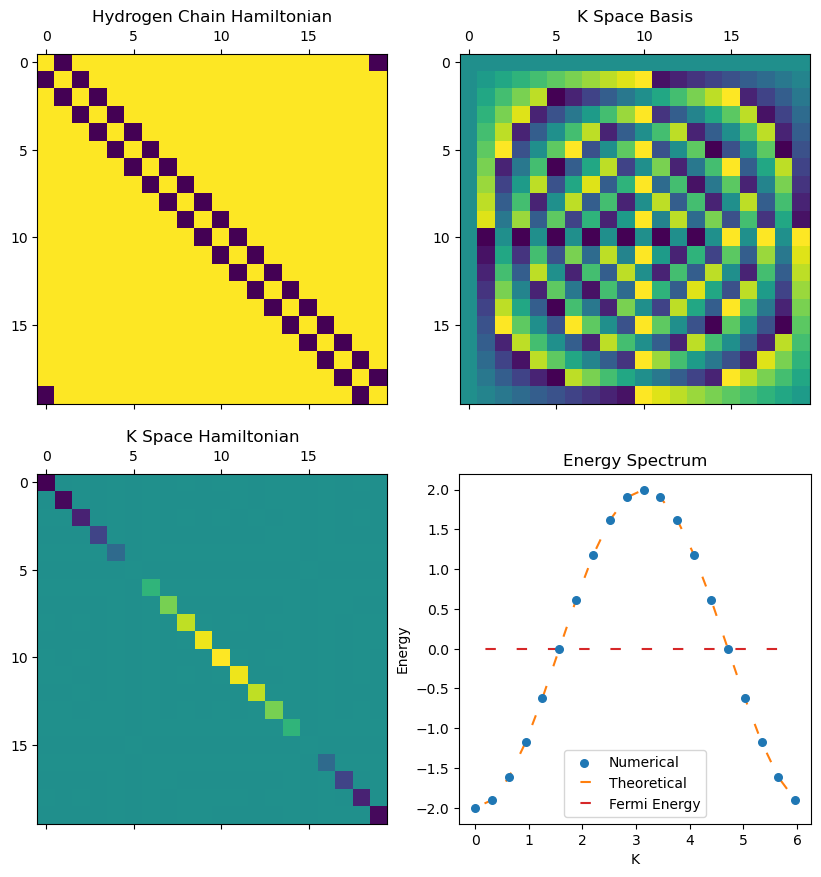

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

Ncell = 20
Natom = 1
a = 1
tau = 0
labels = get_labels(Ncell, Natom)
Ks = np.array([get_K(label, Ncell, a) for label in labels])

H = get_H(Ncell)
assert np.allclose(H, H.H)
ax[0, 0].matshow(H)
ax[0, 0].set_title("Hydrogen Chain Hamiltonian")

F = get_F(Ncell)
assert np.allclose(np.real(F.H @ F), np.eye(Ncell), atol=1e-7)
ax[0, 1].matshow(np.angle(F))
ax[0, 1].set_title("K Space Basis")


Hk = get_Hk(H, F)
assert np.allclose(Hk, Hk.H)
ax[1, 0].matshow(Hk.real)
ax[1, 0].set_title("K Space Hamiltonian")

E = np.diag(Hk).real
E_theory = -2 * np.cos(Ks)
fermi = np.median(E) * np.ones_like(E)

ax[1, 1].scatter(Ks, E.real, label="Numerical", s=30, color="tab:blue", zorder=10)
ax[1, 1].plot(
    Ks, E_theory.real, label="Theoretical", linestyle=LOOSE_DASH, color="tab:orange"
)
ax[1, 1].plot(Ks, fermi, label="Fermi Energy", linestyle=LOOSE_DASH, color="tab:red")
ax[1, 1].legend()
ax[1, 1].set_title("Energy Spectrum")
ax[1, 1].set_xlabel("K")
ax[1, 1].set_ylabel("Energy")


plt.show()

## Distorted Hydrogen Chain

In [13]:
def get_H_distorted(Ncell, Natom):

    N = Ncell * Natom
    H = np.matrix(np.zeros((N, N)))
    labels = get_labels(Ncell, Natom)

    for cell in range(Ncell):

        for atom in range(1, Natom):

            i = get_index((cell + 1, atom), Natom) % N
            j = get_index((cell + 1, atom + 1), Natom) % N
            H[i, j] = -1
            H[j, i] = -1

        i = get_index((cell + 1, 2), Natom) % N
        j = get_index((cell + 2, 1), Natom) % N

        H[i, j] = -0.1
        H[j, i] = -0.1

    return H


def get_F_distorted(Ncell, Natom, a, tau):

    N = Ncell * Natom
    F = np.matrix(np.zeros((N, N)), dtype=complex)
    labels = get_labels(Ncell, Natom)

    for i in range(N):

        for j in range(N):

            if labels[i][1] != labels[j][1]:

                continue

            ri = get_pos(labels[i], a, tau)
            kj = get_K(labels[j], Ncell, a)

            F[i, j] = np.exp(1j * kj * ri) / np.sqrt(Ncell)

    return F


def get_E_distorted(Hk):

    N = Hk.shape[0]

    E_filled = np.zeros(N // 2)
    E_empty = np.zeros(N // 2)
    Ks = []
    for i in range(0, N, 2):

        Hk_block = Hk[i : i + 2, i : i + 2]
        eigvals, _ = la.eigh(Hk_block)
        E_filled[i // 2] = eigvals[0]
        E_empty[i // 2] = eigvals[1]

    return E_filled, E_empty


def get_Ks_distorted(Ncell, Natom, a):

    labels = get_labels(Ncell, Natom)
    Ks = [get_K(labels[i], Ncell, a) for i in range(len(labels)) if i % 2 == 0]

    return Ks

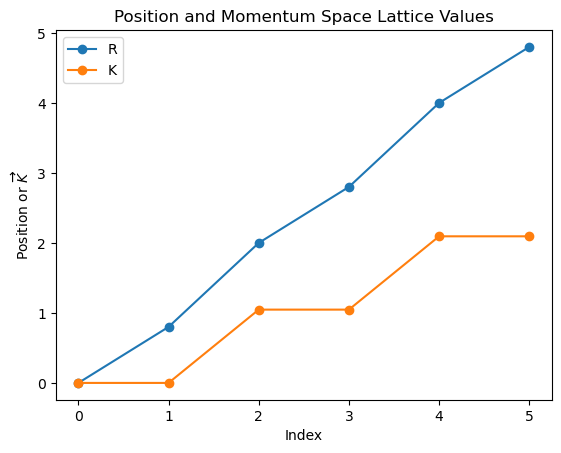

In [14]:
Ncell = 3
Natom = 2
a = 2
tau = 0.8
labels = get_labels(Ncell, Natom)

fig, ax = plt.subplots()
positions = []
positions_k = []
indices = [get_index(label, Natom) for label in labels]
positions = [get_pos(label, a, tau) for label in labels]
Ks = [get_K(label, Ncell, a) for label in labels]

ax.plot(indices, positions, marker="o", color="tab:blue", label="R")
ax.plot(indices, Ks, marker="o", color="tab:orange", label="K")
ax.legend(["R", "K"])
ax.set_xlabel("Index")
ax.set_ylabel("Position or " + r"$\overrightarrow{K}$")
ax.set_title("Position and Momentum Space Lattice Values")
plt.show()

for label in labels:

    assert labels[get_index(label, Natom)] == label

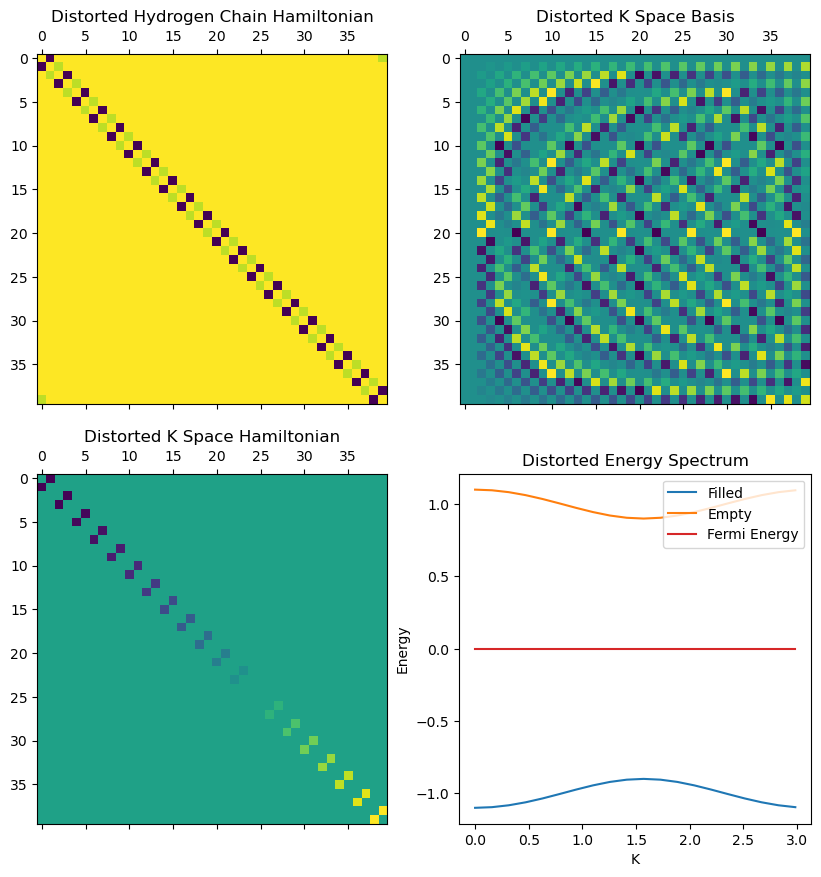

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

Ncell = 20
Natom = 2
a = 2
tau = 0.8
labels = get_labels(Ncell, Natom)
H = get_H_distorted(Ncell, Natom)
assert np.allclose(H, H.H)
ax[0, 0].matshow(H)
ax[0, 0].set_title("Distorted Hydrogen Chain Hamiltonian")

F = get_F_distorted(Ncell, Natom, a, tau)
assert np.allclose(F @ F.H, np.eye(Ncell * Natom), atol=1e-7)
ax[0, 1].matshow(np.angle(F))
ax[0, 1].set_title("Distorted K Space Basis")

Hk = get_Hk(H, F)
assert np.allclose(Hk, Hk.H)
ax[1, 0].matshow(Hk.real)
ax[1, 0].set_title("Distorted K Space Hamiltonian")

E_filled, E_empty = get_E_distorted(Hk)
Ks = get_Ks_distorted(Ncell, Natom, a)

ax[1, 1].plot(Ks, E_filled, color="tab:blue", label="Filled")
ax[1, 1].plot(Ks, E_empty, color="tab:orange", label="Empty")
fermi = np.median([E_filled, E_empty]) * np.ones_like(E_filled)
ax[1, 1].plot(Ks, fermi, color="tab:red", label="Fermi Energy")
ax[1, 1].set_title("Distorted Energy Spectrum")
ax[1, 1].set_xlabel("K")
ax[1, 1].set_ylabel("Energy")
ax[1, 1].legend()

plt.show()

# 2D Graphene

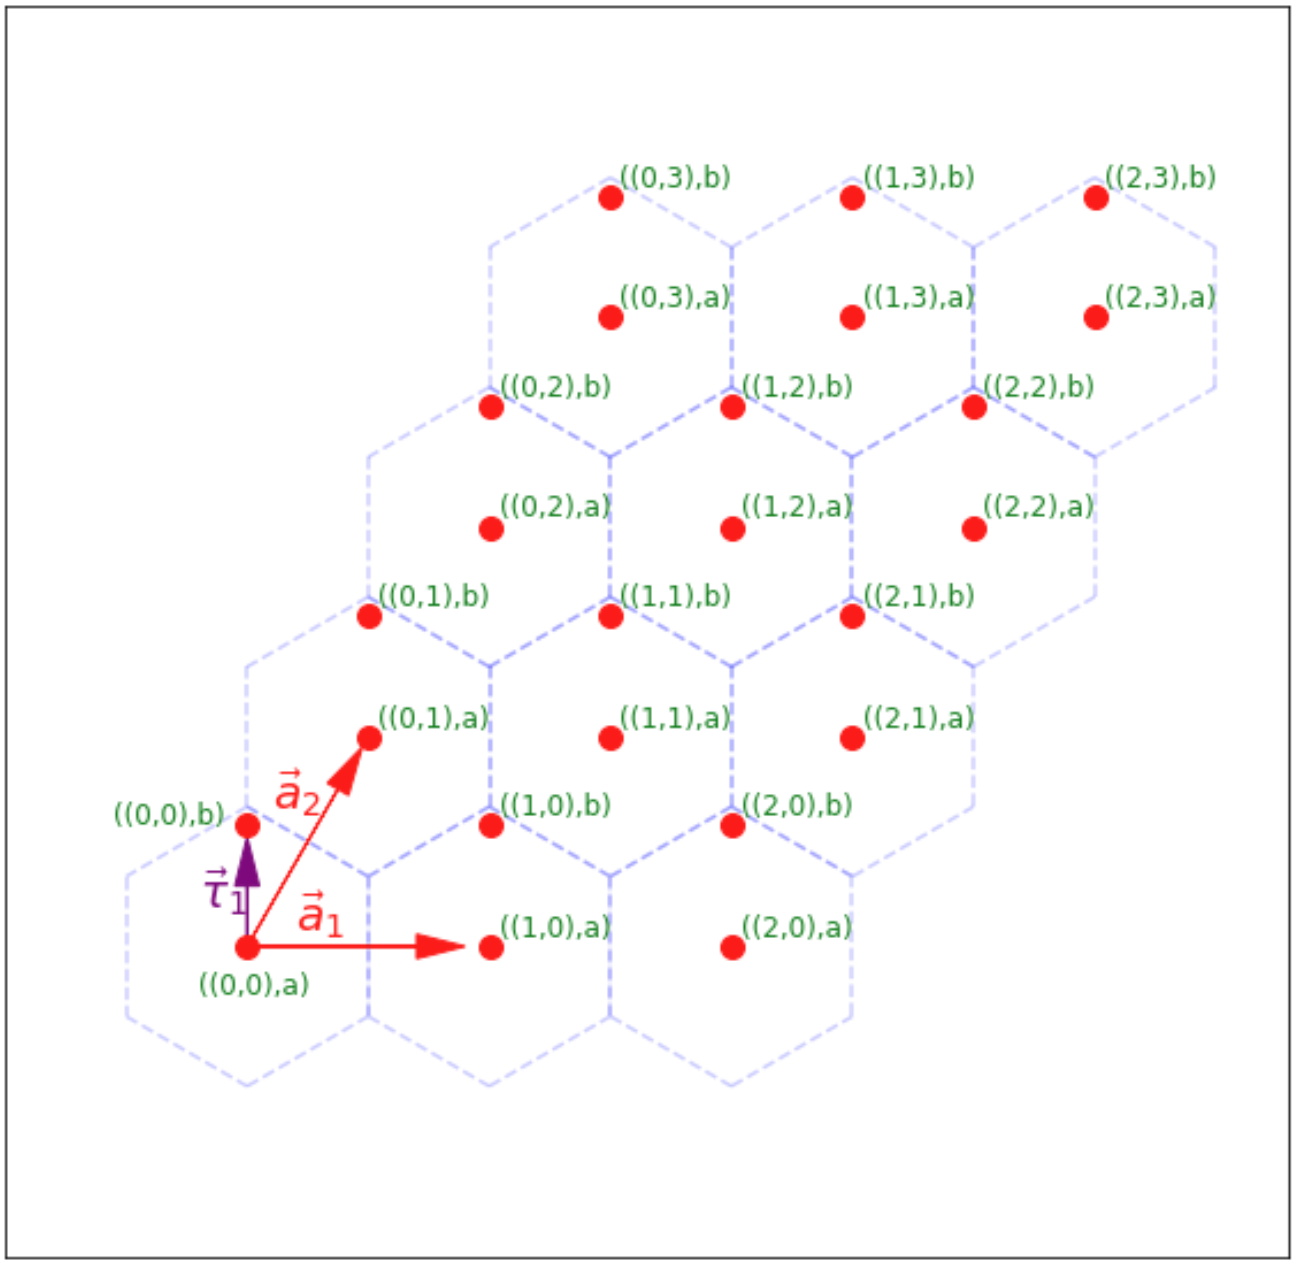{width=50%}

In [181]:
def get_labels_2D(Ncell, Natom, numeric=True):

    labels1 = [i for i in range(1, Ncell[0] + 1)]
    labels2 = [i for i in range(1, Ncell[1] + 1)]

    cell_labels = [[[i, j] * Natom for j in labels2] for i in labels1]
    cell_labels = np.array(cell_labels).reshape(-1, 2)

    if numeric:

        atom_labels = [i for i in range(1, Natom + 1)] * np.prod(Ncell)
    else:
        atom_labels = ALPHABET[:Natom] * np.prod(Ncell)

    labels = list(zip(cell_labels, list(atom_labels)))

    return labels


def get_pos_2D(label, a, tau):

    cell, atom = label
    R = a.T @ (cell - 1) + tau * (atom - 1)
    return np.round(R, 8)


def get_index_2D(label, Ncell, Natom):

    cell, atom = label
    index = (cell[0] - 1) * Natom * Ncell[1] + (cell[1] - 1) * Natom + atom - 1
    return index


def get_K_2D(label, Ncell, a):

    rhs1 = 2 * np.pi * np.array([1 / Ncell[0], 0])
    b1 = np.linalg.solve(a, rhs1)
    rhs2 = 2 * np.pi * np.array([0, 1 / Ncell[1]])
    b2 = np.linalg.solve(a, rhs2)
    b = np.array([b1, b2])

    K = get_pos_2D(label, b, tau=np.zeros(Natom))

    return K

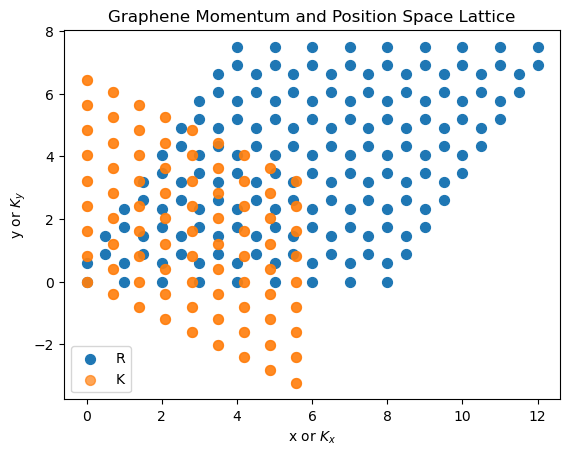

In [183]:
a1 = np.array([1, 0])
a2 = np.array([1 / 2, np.sqrt(3) / 2])
a = np.array([a1, a2])
tau = np.array([0, 1 / np.sqrt(3)])
Ncell1 = 9
Ncell2 = 9
Ncell = np.array([Ncell1, Ncell2])
Natom = 2
labels = get_labels_2D(Ncell, Natom)


for i, label in enumerate(labels):
    assert labels[get_index_2D(label, Ncell, Natom)] == label
    plt.scatter(*get_pos_2D(label, a, tau), s=50, color="tab:blue")
    plt.scatter(*get_K_2D(label, Ncell, a), s=50, color="tab:orange", alpha=0.7)


plt.xlabel("x or " + r"$K_{x}$")
plt.ylabel("y or " + r"$K_{y}$")
plt.title("Graphene Momentum and Position Space Lattice")
plt.legend(["R", "K"])
plt.show()

In [204]:
def get_H_graphene(Ncells, Natom):

    Nx = Ncells[0]
    Ny = Ncells[1]
    N = Nx * Ny * Natom
    H = np.matrix(np.zeros((N, N)))

    for cell_x in range(Nx):

        for cell_y in range(Ny):

            current_x = cell_x + 1
            current_y = cell_y + 1

            # Index for atom type 1 in the current cell
            index_atom_A = get_index_2D(((current_x, current_y), 1), Ncells, Natom)
            # Index for atom type 2 in the current cell
            index_atom_B = get_index_2D(((current_x, current_y), 2), Ncells, Natom)

            # map vertically adjacenet atoms
            H[index_atom_A, index_atom_B] = -1
            H[index_atom_B, index_atom_A] = -1

            # map to type B in left cell
            target_y = (cell_y - 1 + Ny) % Ny + 1
            target_index_atom_B = get_index_2D(
                ((current_x, target_y), 2), Ncells, Natom
            )
            H[index_atom_A, target_index_atom_B] = -1
            H[target_index_atom_B, index_atom_A] = -1

            # map to type B in bottom left cell
            target_x = (cell_x + 1) % Nx + 1
            target_y = (cell_y - 1 + Ny) % Ny + 1
            target_index_atom_B = get_index_2D(((target_x, target_y), 2), Ncells, Natom)
            H[index_atom_A, target_index_atom_B] = -1
            H[target_index_atom_B, index_atom_A] = -1

    return H


def get_F_graphene(Ncell, labels):

    N = len(labels)
    F = np.matrix(np.zeros((N, N)), dtype=complex)
    for i in range(N):

        r = get_pos_2D(labels[i], a, tau)

        for j in range(N):

            if labels[i][1] != labels[j][1]:

                continue

            k = get_K_2D(labels[j], Ncell, a)
            F[i, j] = np.exp(1j * k @ r) / np.sqrt(np.prod(Ncell))

    return F


def get_Hk_graphene(H, F):

    Hk = F.H @ H @ F

    return Hk


def get_E_graphene(Hk):

    N = Hk.shape[0]

    E_filled = np.zeros(N // 2)
    E_empty = np.zeros(N // 2)

    for i in range(0, N, 2):

        Hk_block = Hk[i : i + 2, i : i + 2]
        eigvals, _ = la.eigh(Hk_block)
        E_filled[i // 2] = eigvals[0]
        E_empty[i // 2] = eigvals[1]

    return E_filled, E_empty


def get_Ks_graphene(Ncell, Natom, a):

    labels = get_labels_2D(Ncell, Natom)
    Ks = [get_K_2D(labels[i], Ncell, a) for i in range(len(labels)) if i % 2 == 0]

    return np.array(Ks)

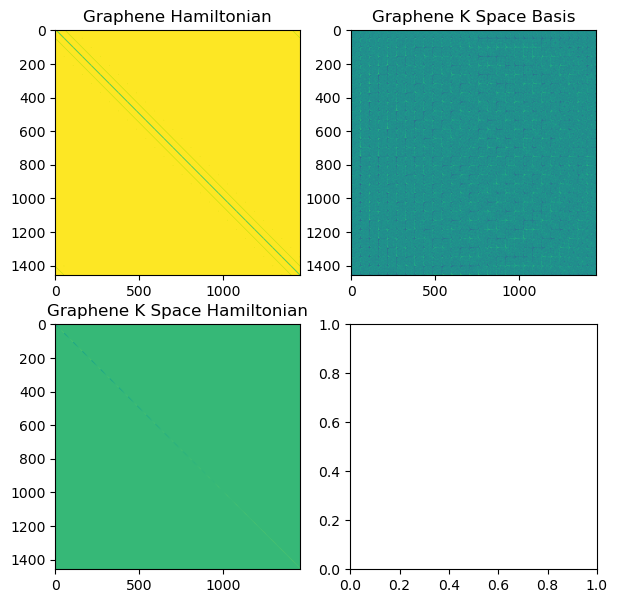

In [205]:
a1 = np.array([1, 0])
a2 = np.array([1 / 2, np.sqrt(3) / 2])
a = np.array([a1, a2])
tau = np.array([0, 1 / np.sqrt(3)])
Ncell1 = 27
Ncell2 = 27
Ncell = np.array([Ncell1, Ncell2])
Natom = 2
labels = get_labels_2D(Ncell, Natom)

fig, ax = plt.subplots(2, 2, figsize=(7, 7))

H = get_H_graphene(Ncell, Natom)
ax[0, 0].imshow(H)
ax[0, 0].set_title("Graphene Hamiltonian")
assert np.allclose(H, H.H)

F = get_F_graphene(Ncell, labels)
ax[0, 1].imshow(np.angle(F))
ax[0, 1].set_title("Graphene K Space Basis")
assert np.allclose(F @ F.H, np.eye(len(labels)), atol=1e-7)

Hk = get_Hk_graphene(H, F)
ax[1, 0].imshow(Hk.real)
ax[1, 0].set_title("Graphene K Space Hamiltonian")
assert np.allclose(Hk, Hk.H)

E_filled, E_empty = get_E_graphene(Hk)
Ks = get_Ks_graphene(Ncell, Natom, a)
plt.show()

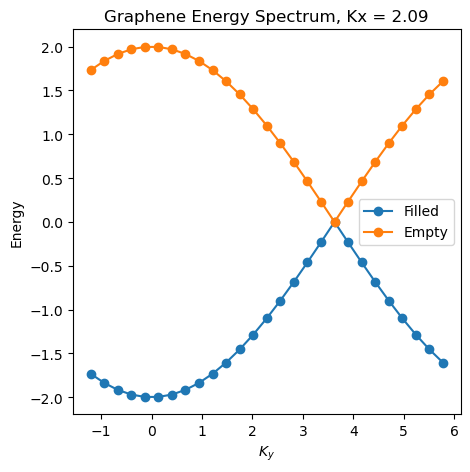

In [206]:
E_filled_mat = E_filled.reshape(Ncell1, Ncell2)
E_empty_mat = E_empty.reshape(Ncell1, Ncell2)
Kx_mat = Ks[:, 0].reshape(Ncell1, Ncell2)
Ky_mat = Ks[:, 1].reshape(Ncell1, Ncell2)

zero_indices = np.where(np.isclose(E_filled_mat, 0.0))
zero_x = zero_indices[0][0]

E1 = E_filled_mat[zero_x, :]
E2 = E_empty_mat[zero_x, :]

Ky = Ky_mat[zero_x, :]


fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax.plot(Ky, E1, color="tab:blue", label="Filled", marker="o")
ax.plot(Ky, E2, color="tab:orange", label="Empty", marker="o")
ax.set_title(f"Graphene Energy Spectrum, Kx = {Kx_mat[zero_x][0]:.2f}")
ax.set_xlabel(r"$K_{y}$")
ax.set_ylabel("Energy")
ax.legend()
plt.show()

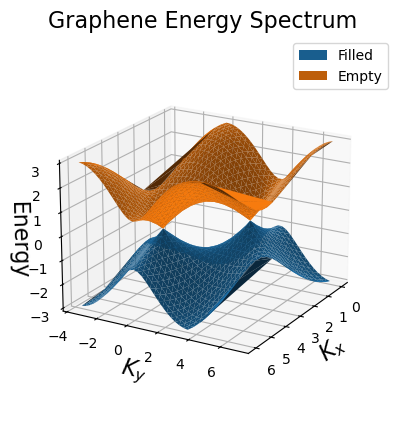

In [196]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(20, 30)
ax.plot_trisurf(Ks[:, 0], Ks[:, 1], E_filled, color="tab:blue", label="Filled")
ax.plot_trisurf(Ks[:, 0], Ks[:, 1], E_empty, color="tab:orange", label="Empty")
ax.set_xlabel(r"$K_{x}$", fontsize=16)
ax.set_ylabel(r"$K_{y}$", fontsize=16)
ax.set_zlabel("Energy", rotation=90, fontsize=16)
ax.set_title("Graphene Energy Spectrum", fontsize=16)
ax.zaxis.labelpad = -0.5

ax.set_box_aspect(None, zoom=0.85)
plt.legend()
plt.show()

# Boron Nitride

In [210]:
def get_H_boron(Ncell, Natom, M):

    Nx = Ncell[0]
    Ny = Ncell[1]
    N = Nx * Ny * Natom
    H = np.matrix(np.zeros((N, N)))

    for cell_x in range(Nx):

        for cell_y in range(Ny):

            current_x = cell_x + 1
            current_y = cell_y + 1

            # Index for atom type 1 in the current cell
            index_atom_A = get_index_2D(((current_x, current_y), 1), Ncell, Natom)
            # Index for atom type 2 in the current cell
            index_atom_B = get_index_2D(((current_x, current_y), 2), Ncell, Natom)

            # map vertically adjacenet atoms
            H[index_atom_A, index_atom_B] = -1
            H[index_atom_B, index_atom_A] = -1

            # add chemical potentials
            H[index_atom_A, index_atom_A] = M
            H[index_atom_B, index_atom_B] = -M

            # map to type B in left cell
            target_y = (cell_y - 1 + Ny) % Ny + 1
            target_index_atom_B = get_index_2D(((current_x, target_y), 2), Ncell, Natom)
            H[index_atom_A, target_index_atom_B] = -1
            H[target_index_atom_B, index_atom_A] = -1

            # map to type B in bottom left cell
            target_x = (cell_x + 1) % Nx + 1
            target_y = (cell_y - 1 + Ny) % Ny + 1
            target_index_atom_B = get_index_2D(((target_x, target_y), 2), Ncell, Natom)
            H[index_atom_A, target_index_atom_B] = -1
            H[target_index_atom_B, index_atom_A] = -1

    return H

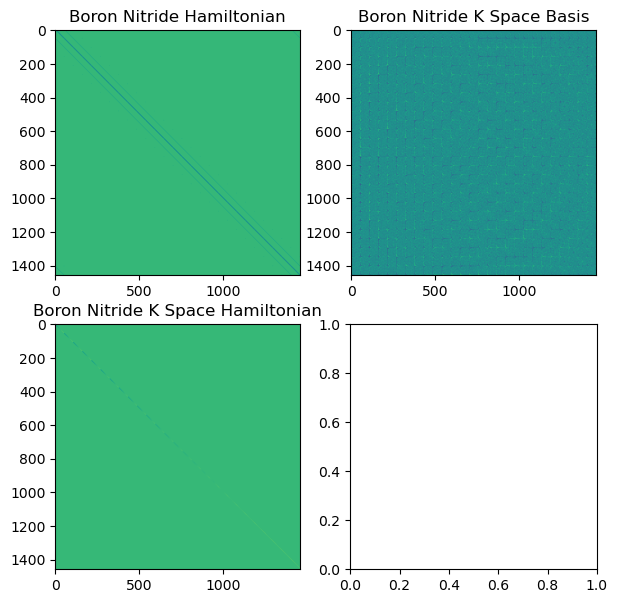

In [208]:
a1 = np.array([1, 0])
a2 = np.array([1 / 2, np.sqrt(3) / 2])
a = np.array([a1, a2])
tau = np.array([0, 1 / np.sqrt(3)])
Ncell1 = 27
Ncell2 = 27
Ncell = np.array([Ncell1, Ncell2])
Natom = 2
labels = get_labels_2D(Ncell, Natom)

fig, ax = plt.subplots(2, 2, figsize=(7, 7))

H = get_H_boron(Ncell, Natom, -0.5)
ax[0, 0].imshow(H)
ax[0, 0].set_title("Boron Nitride Hamiltonian")
assert np.allclose(H, H.H)

F = get_F_graphene(Ncell, labels)
ax[0, 1].imshow(np.angle(F))
ax[0, 1].set_title("Boron Nitride K Space Basis")
assert np.allclose(F @ F.H, np.eye(len(labels)), atol=1e-7)

Hk = get_Hk_graphene(H, F)
ax[1, 0].imshow(Hk.real)
ax[1, 0].set_title("Boron Nitride K Space Hamiltonian")
assert np.allclose(Hk, Hk.H)

E_filled, E_empty = get_E_graphene(Hk)
Ks = get_Ks_graphene(Ncell, Natom, a)

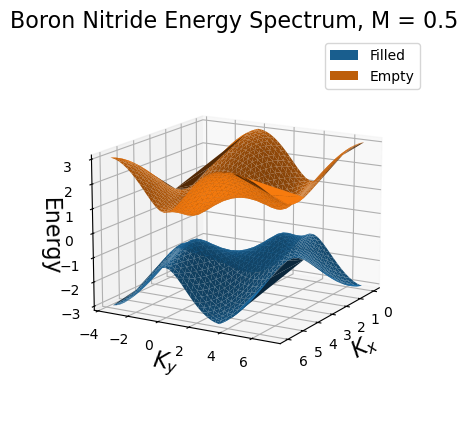

In [209]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(15, 30)
ax.plot_trisurf(Ks[:, 0], Ks[:, 1], E_filled, color="tab:blue", label="Filled")
ax.plot_trisurf(Ks[:, 0], Ks[:, 1], E_empty, color="tab:orange", label="Empty")
ax.set_xlabel(r"$K_{x}$", fontsize=16)
ax.set_ylabel(r"$K_{y}$", fontsize=16)
ax.set_zlabel("Energy", rotation=90, fontsize=16)
ax.set_title(f"Boron Nitride Energy Spectrum, M = {0.5}", fontsize=16)
ax.zaxis.labelpad = -0.5
ax.set_box_aspect(None, zoom=0.85)
plt.legend()
plt.show()

# Haldane Model

In [219]:
def get_H_haldane(Ncell, Natom, M, phi, t):

    Nx, Ny = Ncell
    total_atoms = Nx * Ny * Natom
    H = np.matrix(np.zeros((total_atoms, total_atoms), dtype=complex), dtype=complex)

    for i in range(Nx):
        for j in range(Ny):
            current_x = i + 1
            current_y = j + 1

            # A and B atoms in curr cell
            index_A = get_index_2D(((current_x, current_y), 1), Ncell, Natom)
            index_B = get_index_2D(((current_x, current_y), 2), Ncell, Natom)

            # map same cell neighbors
            H[index_A, index_B] = -1.0
            H[index_B, index_A] = -1.0

            # site potentials
            H[index_A, index_A] = M
            H[index_B, index_B] = -M

            # bottom left neighbor
            bottom_left_x = current_x
            bottom_left_y = (j - 1 + Ny) % Ny + 1

            index_target_A = get_index_2D(
                ((bottom_left_x, bottom_left_y), 1), Ncell, Natom
            )
            index_target_B = get_index_2D(
                ((bottom_left_x, bottom_left_y), 2), Ncell, Natom
            )

            # bottom left interactions
            H[index_A, index_target_B] = -1.0
            H[index_target_B, index_A] = -1.0
            H[index_A, index_target_A] = -t * np.exp(-1j * phi)  # phase shifts
            H[index_target_A, index_A] = -t * np.exp(1j * phi)  # complex NN
            H[index_B, index_target_B] = -t * np.exp(1j * phi)
            H[index_target_B, index_B] = -t * np.exp(-1j * phi)

            # bottom right neighbor
            bottom_right_x = (i + 1) % Nx + 1
            bottom_right_y = (j - 1 + Ny) % Ny + 1

            index_target_A = get_index_2D(
                ((bottom_right_x, bottom_right_y), 1), Ncell, Natom
            )
            index_target_B = get_index_2D(
                ((bottom_right_x, bottom_right_y), 2), Ncell, Natom
            )

            # bottom right interactions
            H[index_A, index_target_B] = -1.0
            H[index_target_B, index_A] = -1.0
            H[index_A, index_target_A] = -t * np.exp(1j * phi)
            H[index_target_A, index_A] = -t * np.exp(-1j * phi)
            H[index_B, index_target_B] = -t * np.exp(-1j * phi)
            H[index_target_B, index_B] = -t * np.exp(1j * phi)

            # Left neighbor
            left_x = (i - 1) % Nx + 1
            left_y = current_y

            index_target_A = get_index_2D(((left_x, left_y), 1), Ncell, Natom)
            index_target_B = get_index_2D(((left_x, left_y), 2), Ncell, Natom)

            # left interactions
            H[index_A, index_target_A] = -t * np.exp(1j * phi)
            H[index_target_A, index_A] = -t * np.exp(-1j * phi)
            H[index_B, index_target_B] = -t * np.exp(-1j * phi)
            H[index_target_B, index_B] = -t * np.exp(1j * phi)

    return H

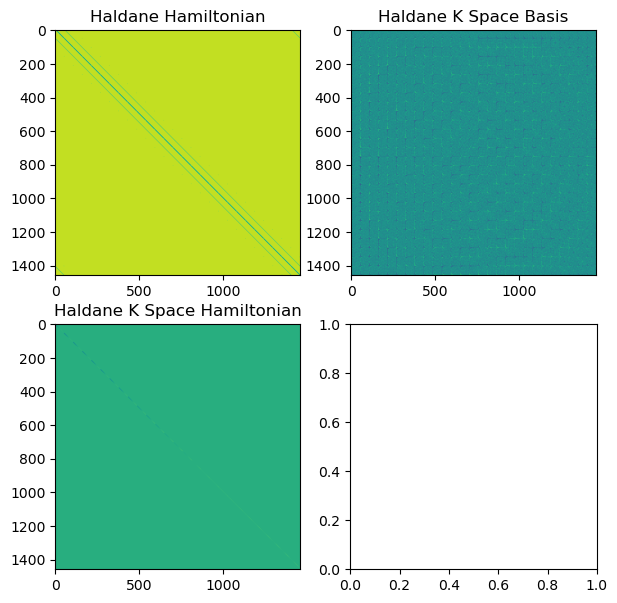

In [217]:
a1 = np.array([1, 0])
a2 = np.array([1 / 2, np.sqrt(3) / 2])
a = np.array([a1, a2])
tau = np.array([0, 1 / np.sqrt(3)])
Ncell1 = 27
Ncell2 = 27
Ncell = np.array([Ncell1, Ncell2])
Natom = 2
labels = get_labels_2D(Ncell, Natom)

fig, ax = plt.subplots(2, 2, figsize=(7, 7))

H = get_H_haldane(Ncell, Natom, 0.1, 0.7, 0.3)
ax[0, 0].imshow(H.real)
ax[0, 0].set_title("Haldane Hamiltonian")
assert np.allclose(H, H.H)

F = get_F_graphene(Ncell, labels)
ax[0, 1].imshow(np.angle(F))
ax[0, 1].set_title("Haldane K Space Basis")
assert np.allclose(F @ F.H, np.eye(len(labels)), atol=1e-7)

Hk = get_Hk_graphene(H, F)
ax[1, 0].imshow(Hk.real)
ax[1, 0].set_title("Haldane K Space Hamiltonian")
assert np.allclose(Hk, Hk.H)

E_filled, E_empty = get_E_graphene(Hk)
Ks = get_Ks_graphene(Ncell, Natom, a)

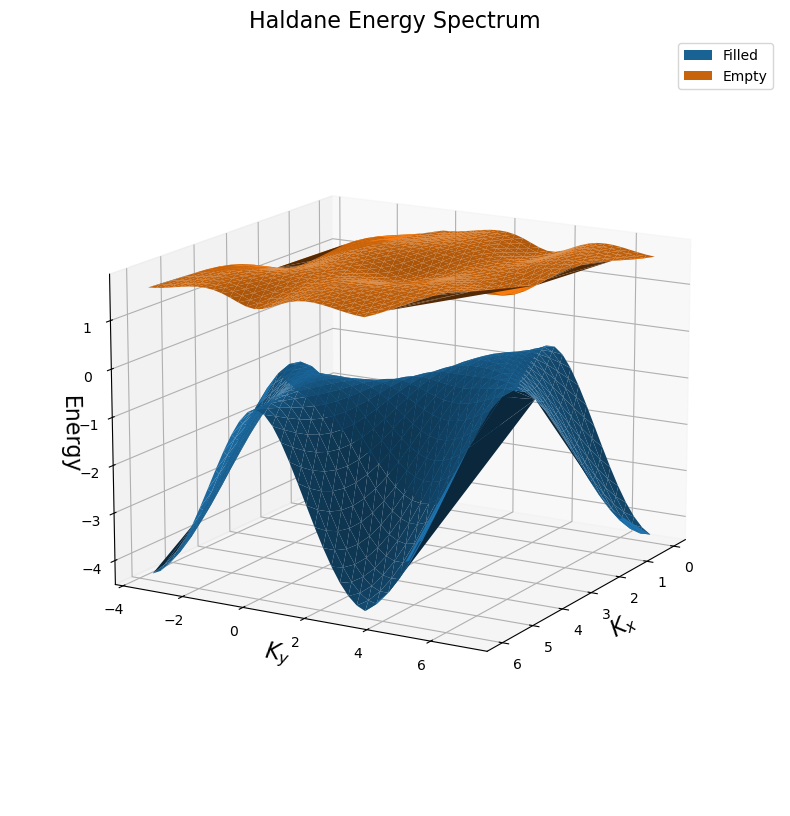

In [218]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(15, 30)
ax.plot_trisurf(Ks[:, 0], Ks[:, 1], E_filled, color="tab:blue", label="Filled")
ax.plot_trisurf(Ks[:, 0], Ks[:, 1], E_empty, color="tab:orange", label="Empty")
ax.set_xlabel(r"$K_{x}$", fontsize=16)
ax.set_ylabel(r"$K_{y}$", fontsize=16)
ax.set_zlabel("Energy", rotation=90, fontsize=16)
ax.set_title(f"Haldane Energy Spectrum", fontsize=16)
ax.zaxis.labelpad = -0.5
ax.set_box_aspect(None, zoom=0.85)
plt.legend()
plt.show()

# Insulators

In [ ]:
Ms = [0, 0.8, 1.0, 1.2, 2.0]
min_gap = []

for M in Ms:

    H = get_H_haldane(Ncell, Natom, labels, M, 0.7, 0.3)
    F = get_F_graphene(Ncell, Natom, labels)
    Hk = get_Hk_graphene(H, F)
    E_filled, E_empty = get_E_graphene(Hk)
    min_gap.append(np.min(np.abs(E_empty - E_filled)))

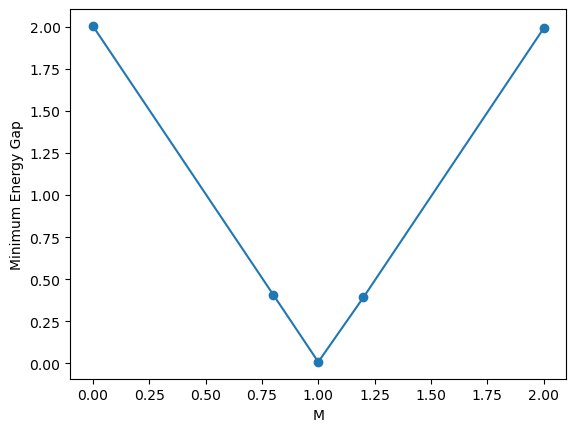

In [ ]:
plt.plot(Ms, min_gap, marker="o", color="tab:blue")
plt.xlabel("M")
plt.ylabel("Minimum Energy Gap")
plt.show()

### Berry Curvature

In [247]:
def get_berry(Hk, Ncell):

    N1, N2 = Ncell

    eigvecs = []
    berry = []
    for j in range(N1):
        eigvecs.append([])

        for k in range(N2):

            i = get_index_2D(((j + 1, k + 1), 1), Ncell, Natom)
            mat = Hk[i : i + 2, i : i + 2]
            _, evecs = np.linalg.eigh(mat)
            eigvecs[-1].append(evecs[:, 0])

    for j in range(N1):
        berry.append([])
        for k in range(N2):
            berry[-1].append(
                np.angle(
                    eigvecs[j][k].H
                    @ eigvecs[(j + 1) % N1][k]
                    * eigvecs[(j + 1) % N1][k].H
                    @ eigvecs[(j + 1) % N1][k - 1]
                    * eigvecs[(j + 1) % N1][k - 1].H
                    @ eigvecs[j][k - 1]
                    * eigvecs[j][k - 1].H
                    @ eigvecs[j][k]
                )[0, 0]
            )

    return np.array(berry)

In [225]:
a1 = np.array([1, 0])
a2 = np.array([1 / 2, np.sqrt(3) / 2])
a = np.array([a1, a2])
tau = np.array([0, 1 / np.sqrt(3)])
Ncell1 = 27
Ncell2 = 27
Ncell = np.array([Ncell1, Ncell2])
Natom = 2
labels = get_labels_2D(Ncell, Natom)
M = 0.8
H = get_H_haldane(Ncell, Natom, M, 0.7, 0.3)
F = get_F_graphene(Ncell, labels)
Hk = get_Hk_graphene(H, F)

(1458, 1458)

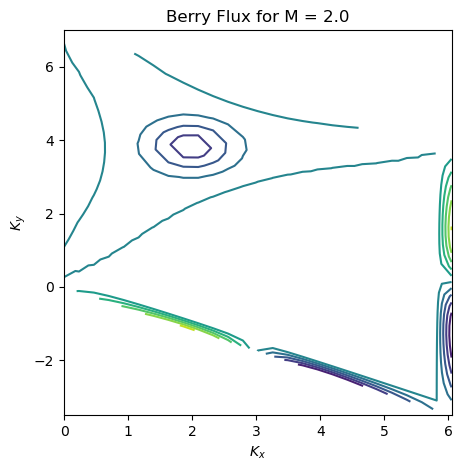

In [253]:
berry = get_berry(Hk, Ncell)
Ks = get_Ks_graphene(Ncell, Natom, a)
Kx = Ks[:, 0].reshape(Ncell1, Ncell2)
Ky = Ks[:, 1].reshape(Ncell1, Ncell2)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.contour(Kx, Ky, berry, levels=10)
ax.set_xlabel(r"$K_{x}$")
ax.set_ylabel(r"$K_{y}$")
ax.set_title(f"Berry Flux for M = {M}")
plt.show()

## Chern Number

In [250]:
Ms = np.linspace(0, 2, 10)
cherns = np.zeros_like(Ms)
N1, N2 = Ncell
ci = 0
for M in Ms:

    H = get_H_haldane(Ncell, Natom, M, 0.7, 0.3)
    F = get_F_graphene(Ncell, labels)
    Hk = get_Hk_graphene(H, F)
    berry = get_berry(Hk, Ncell)
    chern = np.sum(berry) / (2 * np.pi)
    cherns[ci] = chern
    ci += 1

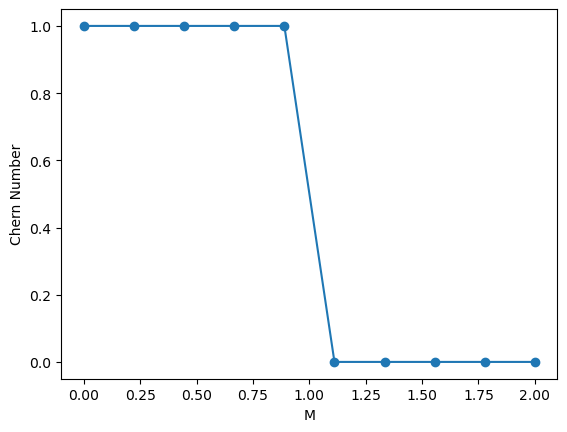

In [252]:
plt.plot(Ms, cherns, marker="o", color="tab:blue")
plt.xlabel("M")
plt.ylabel("Chern Number")
plt.show()

# Non-periodic Hamiltonian

26


Text(0.5, 1.0, 'Energy Bands vs. kx for Edge Modes')

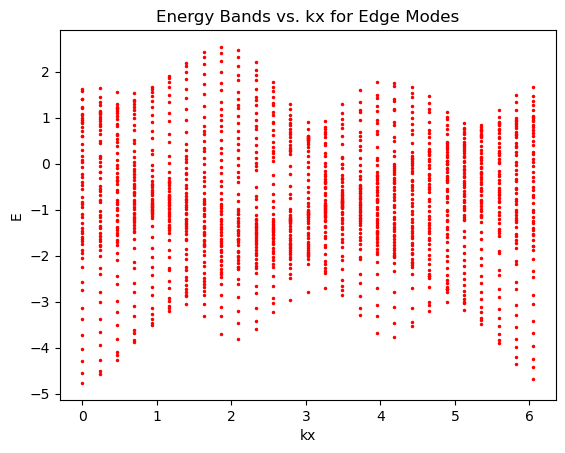

In [ ]:
yarrs = []
xarr = []
for j in range(N1):
    xarr.append(get_K_2D((np.array([j + 1, 1]), 1), Ncell, a)[0])

    i = get_index_2D(((j + 1, 1), 1), Ncell, Natom)
    # if j==0: plt.matshow(np.abs(HK[i:i+4*N2, i:i+4*N2])); plt.show()
    HK = Hk.copy()
    yarrs.append(np.linalg.eigh(HK[i : i + 2 * N2, i : i + 2 * N2])[0])
print(j)
xarr = np.array(xarr)
yarrs = np.array(yarrs)
for yarr in yarrs.T:

    plt.plot(xarr, yarr, "ro", markersize=1.5)
plt.xlabel("kx")
plt.ylabel("E")
plt.title("Energy Bands vs. kx for Edge Modes")
# plt.show()